<h5> Imports </h5>

In [2]:
from dotenv import load_dotenv
import os
import json

from azure.identity import DefaultAzureCredential
from openai import AzureOpenAI

import fitz 
import numpy as np
from paddleocr import PaddleOCR

load_dotenv()

True

<h5> Experimenting with PaddleOCR, drawback is that it is slow with documents with a high number of pages </h5>

In [3]:
def ocr_document(pdf_path: str, dpi: int = 300, lang: str = "en", conf_min: float = 0.5, native_min_chars: int = 40):
    """
    OCR a single PDF document (path).
    - Extracts native text if available.
    - Falls back to PaddleOCR for scanned pages.
    Returns: list of dicts [{page, method, text}]
    """
    # Initialize PaddleOCR with correct parameters for v3.x
    ocr = PaddleOCR(use_textline_orientation=True, lang=lang)

    def page_to_image(page):
        zoom = dpi / 72
        mat = fitz.Matrix(zoom, zoom)
        pix = page.get_pixmap(matrix=mat, alpha=False)
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.h, pix.w, pix.n)
        if pix.n == 4:
            img = img[:, :, :3]
        return img

    doc = fitz.open(pdf_path)
    pages = []

    for i, page in enumerate(doc, start=1):
        native_text = (page.get_text("text") or "").strip()

        if len(native_text) >= native_min_chars:
            text = native_text
            method = "native"
        else:
            img = page_to_image(page)
            result = ocr.predict(img)
            lines = []
            if result and result[0]:
                for line in result[0]:
                    if line and len(line) >= 2:
                        # Structure: [[bbox], (text, confidence)]
                        txt, conf = line[1][0], line[1][1]
                        if conf >= conf_min:
                            lines.append(txt.strip())
            text = "\n".join(lines).strip()
            method = "ocr"

        pages.append({"page": i, "method": method, "text": text})

    doc.close()
    return pages

<h5> Since we just need a text, plain pdf to text should do the job. </h5>

In [4]:
def extract_pdf_text_simple(pdf_path: str):
    """
    Extract text from PDF using native text extraction only.
    Returns: list of dicts [{page, text}]
    """
    doc = fitz.open(pdf_path)
    pages = []
    
    for i, page in enumerate(doc, start=1):
        text = page.get_text("text").strip()
        pages.append({
            "page": i,
            "text": text,
            "method": "mypdf"
        })
    
    doc.close()
    return pages

<h5> Getting the embedding with the normalization is required because

In [5]:
azure_client = AzureOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION")
)

def normalize(v):
    """ Normalize a vector to unit length """
    v = np.array(v, dtype="float32")
    norm = np.linalg.norm(v)
    return v / norm if norm > 0 else v


def get_text_embedding(text, normalizeEmbedding=True, model="text-embedding-3-large"):
    """ Get text embedding from Azure OpenAI and optionally normalize it """
    emb = azure_client.embeddings.create(input=[text], model=model).data[0].embedding
    if normalizeEmbedding:
        emb = normalize(emb)
    return emb

In [ ]:
import glob

# Process all PDFs in data folder

all_results = []

pdf_files = glob.glob("data/*.pdf")

print(f"Found {len(pdf_files)} PDF files")

for pdf_path in pdf_files:
    try:
        print(f"Processing: {pdf_path}: {pdf_files.index(pdf_path)+1}/{len(pdf_files)}")
        pages = extract_pdf_text_simple(pdf_path)
        all_results.append({
            "file": pdf_path,
            "pages": pages
        })
        print(f"Extracted {len(pages)} pages")
    except Exception as e:
        print(f"Error processing {pdf_path}: {e}")

print(f"Total files processed: {len(all_results)}")

Found 1069 PDF files
Processing: data/Xi_LP_200W_0.3-1.05A_S1_WL_I195_929002879180.pdf: 1/1069
Extracted 8 pages
Processing: data/fortimo-led-linear-dig.pdf: 2/1069
Extracted 60 pages
Processing: data/fortimo-slm-c-1203-L09-1619-g7-he.pdf: 3/1069
Extracted 9 pages
Processing: data/Fortimo_LED_Strip_OC_2ft_2200lm_9xx_HV5_.pdf: 4/1069
Extracted 8 pages
Processing: data/Xitanium_42W_a_0.9_1.05A_40V_3CG_230V_929001476706.pdf: 5/1069
Extracted 7 pages
Total files processed: 5


<h5> Retrieve the embedding for each page of each document. </h5>

In [7]:
for doc_result in all_results:
    file_name = doc_result["file"]
    pages = doc_result["pages"]
    
    print(f"Processing embeddings for: {file_name}")
    
    page_embeddings = []
    
    for page_data in pages:
        text = page_data["text"]
        
        if text.strip():
            try:
                embedding = get_text_embedding(text, normalizeEmbedding=True)
                page_embeddings.append(embedding)
                print(f"Page {page_data['page']}: embedding calculated ({len(embedding)} dims)")
            except Exception as e:
                print(f"Page {page_data['page']}: error - {e}")
        else:
            print(f"Page {page_data['page']}: empty text, skipping")
    
    doc_result["embeddings"] = page_embeddings

Processing embeddings for: data/Xi_LP_200W_0.3-1.05A_S1_WL_I195_929002879180.pdf
Page 1: embedding calculated (3072 dims)
Page 2: embedding calculated (3072 dims)
Page 3: embedding calculated (3072 dims)
Page 4: embedding calculated (3072 dims)
Page 5: embedding calculated (3072 dims)
Page 6: embedding calculated (3072 dims)
Page 7: embedding calculated (3072 dims)
Page 8: embedding calculated (3072 dims)
Processing embeddings for: data/fortimo-led-linear-dig.pdf
Page 1: embedding calculated (3072 dims)
Page 2: embedding calculated (3072 dims)
Page 3: embedding calculated (3072 dims)
Page 4: embedding calculated (3072 dims)
Page 5: embedding calculated (3072 dims)
Page 6: embedding calculated (3072 dims)
Page 7: embedding calculated (3072 dims)
Page 8: embedding calculated (3072 dims)
Page 9: embedding calculated (3072 dims)
Page 10: embedding calculated (3072 dims)
Page 11: embedding calculated (3072 dims)
Page 12: embedding calculated (3072 dims)
Page 13: embedding calculated (3072 d

In [9]:
all_results[0]

{'file': 'data/Xi_LP_200W_0.3-1.05A_S1_WL_I195_929002879180.pdf',
 'pages': [{'page': 1,
   'text': 'Xitanium\nLED driver\nDatasheet\nXitanium LITE Prog LED drivers Independent\nXi LP 200W 0.3-1.05A S1 WL I195\n9290 028 79180\nPhilips Xitanium Lite Programmable LED drivers are value engineered to deliver a carefully selected feature set and high-end performance,\nmaking it a preferred choice for many outdoor applications. The portfolio offers high flexibility with a customizable operating window,\nenabling differentiation in LED lighting designs via system tuning and being prepared for LED efficacy upgrades.  \n In this product family Philips introduces new drivers in a stretched form factor with a balanced feature set, which offer high value for both\nOEM customers and end-users. The products can replace the existing programmable outdoor LED drivers and will bring significant\nimprovement in programming, assembly into a luminaire and electrical performance. One of the key features is 

In [ ]:
# Create embeddings folder
embeddings_dir = os.path.join("data_output", "embeddings")
os.makedirs(embeddings_dir, exist_ok=True)

# Save each document to a separate file
for idx, doc in enumerate(all_results):
    # Create a filename based on the original PDF name
    original_filename = os.path.basename(doc["file"])
    base_name = os.path.splitext(original_filename)[0]
    output_filename = f"{base_name}_embeddings.json"
    output_path = os.path.join(embeddings_dir, output_filename)
    
    # Convert numpy arrays to lists for JSON serialization
    doc_to_save = doc.copy()
    if "embeddings" in doc_to_save:
        doc_to_save["embeddings"] = [emb.tolist() if isinstance(emb, np.ndarray) else emb 
                                      for emb in doc_to_save["embeddings"]]
    
    # Save individual document
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(doc_to_save, f, indent=2, ensure_ascii=False)
    
    print(f"Saved: {output_filename}")

print(f"\nTotal files saved: {len(all_results)}")
print(f"Saved to folder: {embeddings_dir}")

✓ Saved: Xi_LP_200W_0.3-1.05A_S1_WL_I195_929002879180_embeddings.json
✓ Saved: fortimo-led-linear-dig_embeddings.json
✓ Saved: fortimo-slm-c-1203-L09-1619-g7-he_embeddings.json
✓ Saved: Fortimo_LED_Strip_OC_2ft_2200lm_9xx_HV5__embeddings.json
✓ Saved: Xitanium_42W_a_0.9_1.05A_40V_3CG_230V_929001476706_embeddings.json

✓ Total files saved: 5
✓ Saved to folder: data_output/embeddings


<h5> Compute a weighted mean from individual chunks (page embeddings) for each document </h5>

In [ ]:
import json
import glob

# Read all JSON files from embeddings folder
embeddings_dir = os.path.join("data_output", "embeddings")
embeddings_files = glob.glob(os.path.join(embeddings_dir, "*.json"))

all_results = []

print(f"Found {len(embeddings_files)} JSON files in {embeddings_dir}")

for json_file in embeddings_files:
    try:
        with open(json_file, "r", encoding="utf-8") as f:
            doc_data = json.load(f)
            all_results.append(doc_data)
        print(f"Loaded: {os.path.basename(json_file)}")
    except Exception as e:
        print(f"Error loading {json_file}: {e}")

print(f"\nTotal documents loaded: {len(all_results)}")

Found 1068 JSON files in data_output/embeddings
✓ Loaded: Fortimo_LED_Strip_5ft_MF_9xx_LV6_embeddings.json
✓ Loaded: dig-sr-connector_embeddings.json
✓ Loaded: Fortimo_LED_Strip_0.25ft_MF_9xx_HV6_x_2pcs_embeddings.json
✓ Loaded: 202308-1-design-in-guide-led-indoor-driver-spot-downlight_embeddings.json
✓ Loaded: SIG-Xitanium-SR-Bridge-DIG-A11_embeddings.json
✓ Loaded: Datasheet_LED_Transformer_75W_24VDC_120-277V_IP67_929003413906_embeddings.json
✓ Loaded: Fortimo-LED-Square-1250lm-9xx-HV-LV3_embeddings.json
✓ Loaded: Fortimo_LED_Strip_CED_1ft_MF_FC_LV5__embeddings.json
✓ Loaded: Fortimo-LED-Strip-PR-FT-2ft-2200lm-927-965-FC-HV5_embeddings.json
✓ Loaded: Datasheet-Fortimo-1100-lm_embeddings.json
✓ Loaded: Fortimo_LED_Line_1ft_MF_8xx_1R_LV5__embeddings.json
✓ Loaded: LED_Transformer_120W_24VDC_913710032567_embeddings.json
✓ Loaded: Fortimo_SLM_C_1201_L09_1313_G7N_HE_plus__embeddings.json
✓ Loaded: Fortimo_LED_Strip_2ft_2200lm_9xx_LV4__embeddings.json
✓ Loaded: Fortimo_FastFlex_2x6_DA_G4pl

In [6]:
all_results[3]

{'file': 'data/202308-1-design-in-guide-led-indoor-driver-spot-downlight.pdf',
 'pages': [{'page': 1,
   'text': 'August 2023\nDesign-in Guide\nReliable technology for \nstand-alone and \nconnected LED solutions\nLED Indoor drivers\nSpot & Downlight',
   'method': 'mypdf'},
  {'page': 2,
   'text': '3\nDesign-in Guide - Philips Xitanium LED indoor drivers - Spot & Downlight\nContents\n4\n4\n4\n4\n5\n5\n6\n6\n6\n6\n7\n10\n11\n12\n12\n13\n14\n15\n15\n16\n16\n17\n19\n22\n23\n24\n24\n24\n25\n26\n27\nIntroduction to this guide \nApplications  \nInformation and support \nDetermine which documents contain what  \ninformation  \nWarnings and safety instructions Important \nlnstallation instructions\nDisposal\nIntroduction to Xitanium Indoor Spot & \nDownlight LED drivers\nIntroduction\nXitanium driver versions \nXitanium driver segments\nIntroduction to Xitanium SR drivers \nFeatures\nTemporal Light Artefacts (flicker & \nstroboscopic effects) \nDimensions \nDriver naming\nUse in hazardous env

In [9]:
import numpy as np

def weighted_mean_doc_vector(page_embeddings, weights=None):
    if not page_embeddings:
        return None

    V = np.vstack(page_embeddings)  # (n_pages, d)

    if weights is None:
        w = np.ones(len(V), dtype="float32")
    else:
        w = np.asarray(weights, dtype="float32")
        w = w / (w.sum() + 1e-12)

    v = (w[:, None] * V).sum(axis=0)
    v /= (np.linalg.norm(v) + 1e-12)
    return v



In [14]:
for doc_result in all_results:
    page_embeddings = doc_result.get("embeddings", [])
    page_texts = [p.get("text","") for p in doc_result.get("pages", [])]
    v_doc = weighted_mean_doc_vector(page_embeddings)
    doc_result["doc_vector"] = None if v_doc is None else v_doc.tolist()


In [12]:
all_results[150]['doc_vector']

[0.004275821161783936,
 -0.005150897338905314,
 -0.015287601473570507,
 0.029455206387516416,
 -0.00901445332656139,
 0.03186969637198493,
 -0.010923719874042715,
 0.047342384628126316,
 -0.05966813231634519,
 0.02666943009617254,
 0.022185516085179473,
 0.0011148880825143162,
 -0.00179803410863051,
 -0.021679621248062046,
 0.008109274753731566,
 0.024484636203724635,
 0.0157228294652299,
 -0.01106277029287803,
 0.008521507170486052,
 -0.009760770871505264,
 0.015469333753650208,
 -0.01889918592125027,
 -0.048905365047353114,
 0.026206794401519885,
 -0.0017263947601075845,
 0.01481848800227236,
 0.014850301403631899,
 0.012203052746117046,
 -0.02604971690750444,
 -0.009023687828175253,
 0.016961044882970004,
 0.021259393099790694,
 0.014759970276960799,
 -0.033211727279214856,
 -0.06321986441480906,
 -0.04115192831448948,
 0.027406594678337337,
 0.01793801758249828,
 -0.04775098610666873,
 0.04222369990363202,
 -0.013501305019814563,
 -0.03020270141086309,
 0.0244570889547133,
 0.01562

Total documents with vectors: 1064
Vector dimensions: 3072


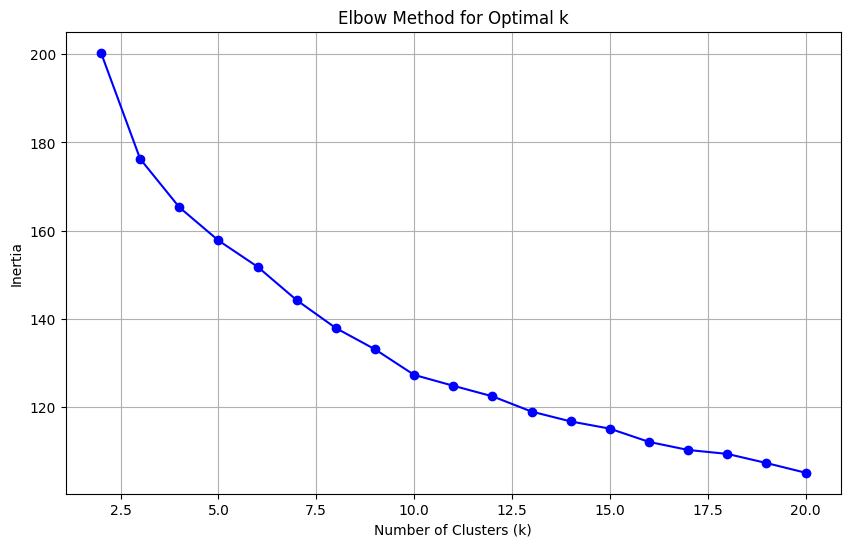


Clustering complete with 8 clusters

Cluster distribution:
Cluster 0: 236 documents
Cluster 1: 161 documents
Cluster 2: 143 documents
Cluster 3: 164 documents
Cluster 4: 131 documents
Cluster 5: 28 documents
Cluster 6: 36 documents
Cluster 7: 165 documents

Sample documents per cluster:

Cluster 0 (236 docs):
  - Xitanium_30W_a_0.6_0.75A_40V_3CW_230V_929002103606.pdf
  - Xitanium-50W_WH_0.7-1.5A_54V_SR_Is_230V_929002861306.pdf
  - Xitanium_60W_0.08-0.35A_300V_TD16CL_230V_929001616006.pdf
  - Xitanium_20W_m_0.15-0.5A_54V_S_TD_230V_929001485106.pdf
  - Xitanium_30W_0.2_0.25A_60-120V_DS_230V_929001695006.pdf
  ... and 231 more

Cluster 1 (161 docs):
  - Fortimo-LED-Square-1250lm-9xx-HV-LV3.pdf
  - Datasheet-Fortimo-1100-lm.pdf
  - Fortimo_LED_Line_1ft_MF_8xx_1R_LV5_.pdf
  - Fortimo_FastFlex_2x6_DA_G4plus.pdf
  - Fortimo_LED_Line_VO_1ft_MF_8xx_3R_HV5_.pdf
  ... and 156 more

Cluster 2 (143 docs):
  - dig-sr-connector.pdf
  - 202308-1-design-in-guide-led-indoor-driver-spot-downlight.pdf
  

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

# Extract doc vectors from all_results
doc_vectors = []
doc_names = []

for doc in all_results:
    if doc.get('doc_vector') is not None:
        doc_vectors.append(doc['doc_vector'])
        # Extract just the filename without path
        filename = os.path.basename(doc['file'])
        doc_names.append(filename)

# Convert to numpy array
doc_vectors_array = np.array(doc_vectors)

print(f"Total documents with vectors: {len(doc_vectors)}")
print(f"Vector dimensions: {doc_vectors_array.shape[1]}")

# Determine optimal number of clusters using elbow method
inertias = []
K_range = range(2, min(21, len(doc_vectors)))

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(doc_vectors_array)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

# Perform clustering with a reasonable number of clusters (e.g., 8)
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(doc_vectors_array)

# Add cluster labels to all_results
cluster_idx = 0
for doc in all_results:
    if doc.get('doc_vector') is not None:
        doc['cluster'] = int(cluster_labels[cluster_idx])
        cluster_idx += 1

# Display clustering results
print(f"\nClustering complete with {n_clusters} clusters")
print("\nCluster distribution:")
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    print(f"Cluster {i}: {count} documents")

# Show sample documents from each cluster
print("\nSample documents per cluster:")
for i in range(n_clusters):
    cluster_docs = [doc_names[j] for j in range(len(doc_names)) if cluster_labels[j] == i]
    print(f"\nCluster {i} ({len(cluster_docs)} docs):")
    # Show first 5 documents
    for doc in cluster_docs[:5]:
        print(f"  - {doc}")
    if len(cluster_docs) > 5:
        print(f"  ... and {len(cluster_docs) - 5} more")

In [18]:
import shutil

# Create main clusters folder
clusters_main_dir = os.path.join("data_output", "clusters")
os.makedirs(clusters_main_dir, exist_ok=True)

# Create subfolders for each cluster and copy PDF files
for cluster_id in range(n_clusters):
    # Create cluster subfolder
    cluster_dir = os.path.join(clusters_main_dir, f"cluster{cluster_id}")
    os.makedirs(cluster_dir, exist_ok=True)
    
    # Get documents in this cluster
    cluster_doc_count = 0
    for doc in all_results:
        if doc.get('cluster') == cluster_id:
            # Get original PDF path
            original_pdf_path = doc['file']
            
            # Check if PDF file exists
            if os.path.exists(original_pdf_path):
                # Get just the filename
                pdf_filename = os.path.basename(original_pdf_path)
                
                # Destination path
                dest_path = os.path.join(cluster_dir, pdf_filename)
                
                # Copy PDF file to cluster folder
                shutil.copy2(original_pdf_path, dest_path)
                cluster_doc_count += 1
            else:
                print(f"  ⚠ PDF not found: {original_pdf_path}")
    
    print(f"✓ Cluster {cluster_id}: {cluster_doc_count} PDF files copied to {cluster_dir}")

print(f"\n✓ All PDF files organized into {clusters_main_dir}")

✓ Cluster 0: 236 PDF files copied to data_output/clusters/cluster0
✓ Cluster 1: 161 PDF files copied to data_output/clusters/cluster1
✓ Cluster 2: 143 PDF files copied to data_output/clusters/cluster2
✓ Cluster 3: 164 PDF files copied to data_output/clusters/cluster3
✓ Cluster 4: 131 PDF files copied to data_output/clusters/cluster4
✓ Cluster 5: 28 PDF files copied to data_output/clusters/cluster5
✓ Cluster 6: 36 PDF files copied to data_output/clusters/cluster6
✓ Cluster 7: 165 PDF files copied to data_output/clusters/cluster7

✓ All PDF files organized into data_output/clusters


In [17]:
import shutil

# Create main clusters folder
clusters_main_dir = os.path.join("data_output", "clusters")
os.makedirs(clusters_main_dir, exist_ok=True)

# Create subfolders for each cluster and copy files
for cluster_id in range(n_clusters):
    # Create cluster subfolder
    cluster_dir = os.path.join(clusters_main_dir, f"cluster{cluster_id}")
    os.makedirs(cluster_dir, exist_ok=True)
    
    # Get documents in this cluster
    cluster_doc_count = 0
    for doc in all_results:
        if doc.get('cluster') == cluster_id:
            # Get original filename
            original_filename = os.path.basename(doc['file'])
            base_name = os.path.splitext(original_filename)[0]
            
            # Source file path (in embeddings folder)
            source_file = os.path.join(embeddings_dir, f"{base_name}_embeddings.json")
            
            # Destination file path
            dest_file = os.path.join(cluster_dir, f"{base_name}_embeddings.json")
            
            # Copy file to cluster folder
            if os.path.exists(source_file):
                shutil.copy2(source_file, dest_file)
                cluster_doc_count += 1
    
    print(f"✓ Cluster {cluster_id}: {cluster_doc_count} files copied to {cluster_dir}")

print(f"\n✓ All files organized into {clusters_main_dir}")

✓ Cluster 0: 236 files copied to data_output/clusters/cluster0
✓ Cluster 1: 161 files copied to data_output/clusters/cluster1
✓ Cluster 2: 143 files copied to data_output/clusters/cluster2
✓ Cluster 3: 164 files copied to data_output/clusters/cluster3
✓ Cluster 4: 131 files copied to data_output/clusters/cluster4
✓ Cluster 5: 28 files copied to data_output/clusters/cluster5
✓ Cluster 6: 36 files copied to data_output/clusters/cluster6
✓ Cluster 7: 165 files copied to data_output/clusters/cluster7

✓ All files organized into data_output/clusters
